# CNN Deconv Topological studies

Study the performance of NEXT classical toplogocal method using data previously deconvoluted bu Martin's CNN

25/11/24 Santiago

In [95]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore")

In [96]:
import glob
import sys
from os import listdir
from collections import namedtuple
import itertools as itertools

In [97]:
import numpy             as np
import pandas            as pd
import tables            as tb
from   scipy             import stats
from   scipy             import optimize
import networkx as nx

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

plt.rcParams['image.cmap'] = 'rainbow'

In [98]:
pypaths = ('/home/usc/ie/jhm/NEXT/nextana',
           '/home/usc/ie/jhm/NEXT/hipy', 
           '/home/usc/ie/jjhm/NEXT/IC')
for ipypath in pypaths:
       sys.path.insert(0,ipypath)

In [99]:
import nana.topo.evtfun    as evtfun
import nana.topo.graphfun  as graphfun

In [100]:
import hipy.utils        as ut

#import hipy.histos       as histos
import hipy.pltext       as pltext
#import hipy.profile      as prof
#from invisible_cities.io.dst_io import load_dst, load_dsts
from hipy.styles import style
style()

## Load data


In [101]:
datafilename = 'dataset_15607_DEP_deco.h5'
mcfilename   = 'dataset_4bar_MC_DEP_deco.h5'
datapath     = '/mnt/netapp1/Store_next_data/NEXT100/deco_seg/'

In [102]:
ifilename = datapath + datafilename
print(f'loading {ifilename}')
data     =  pd.read_hdf(ifilename, 'DATASET/Voxels');
bin_info =  pd.read_hdf(ifilename, 'DATASET/BinsInfo');
bin_widths  = evtfun.get_bin_widths(bin_info)

loading /mnt/netapp1/Store_next_data/NEXT100/deco_seg/dataset_15607_DEP_deco.h5


In [103]:
data

,dataset_id,binclass,xbin,ybin,zbin,energy,decolabel,decoscore,decopred
0,0,-1,24,44,77,0.000237,-1,0.087309,0
1,0,-1,25,45,77,0.000301,-1,0.076018,0
2,0,-1,25,45,78,0.000468,-1,0.084663,0
3,0,-1,25,46,77,0.000253,-1,0.067720,0
4,0,-1,25,46,78,0.000197,-1,0.069409,0
...,...,...,...,...,...,...,...,...,...
6805395,10777,-1,27,15,23,0.000210,-1,0.093303,0
6805396,10777,-1,27,21,23,0.000190,-1,0.087002,0
6805397,10777,-1,27,23,9,0.000216,-1,0.069199,0
6805398,10777,-1,27,24,9,0.000611,-1,0.083242,0


### Get the deconv data (share the energy)

In [104]:
datadeco   = evtfun.get_deconvoluted_data(data)
#evtfun.test_get_deconvoluted_data(data)
datadeco = datadeco[datadeco.decopred == 1].copy()

## Display an event

In [105]:
ievent   = 22 # 22

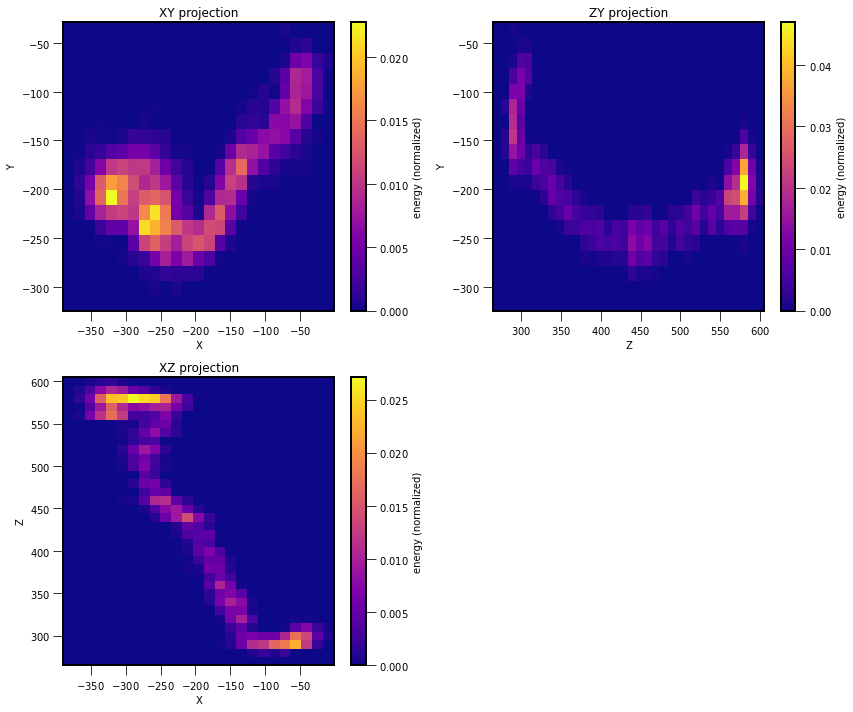

In [106]:
style('--')
evt   = data.groupby('dataset_id').get_group(ievent)
coors = evtfun.get_coors(evt, bin_info)
bins  = evtfun.get_bins(coors, bin_widths)
ene   = evt.energy.values 
evtfun.event_display(coors, bins, ene = ene);


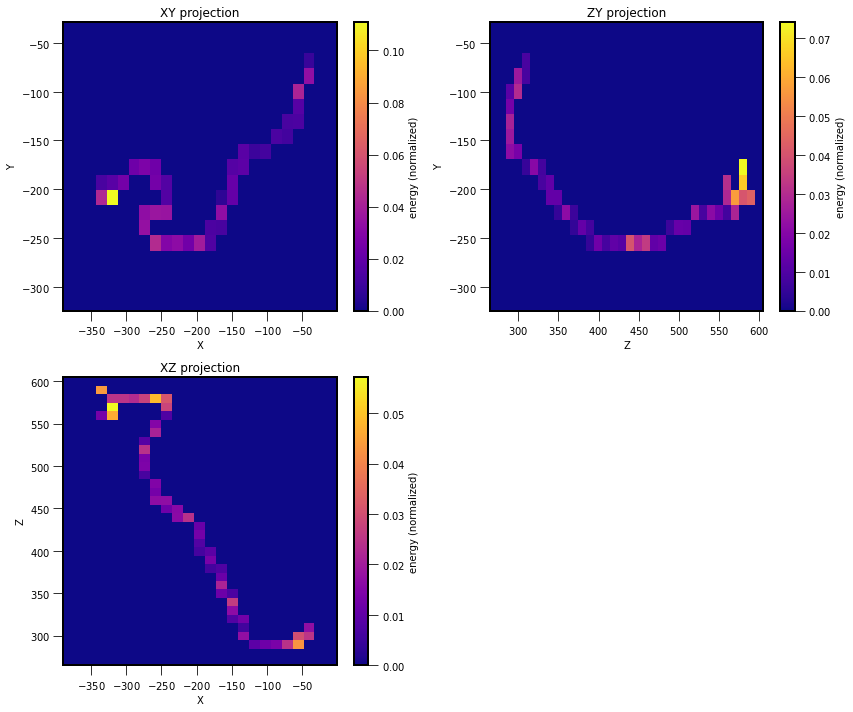

In [107]:
#evtdeco   = evtfun.get_deconvoluted_data(evt)
evtdeco   = datadeco.groupby('dataset_id').get_group(ievent)
coorsdeco = evtfun.get_coors(evtdeco, bin_info)
enedeco   = evtdeco.enecn.values
evtfun.event_display(coorsdeco, bins = bins, ene = enedeco);

In [108]:
print(f" total corrected and normalized energy of deco hits = ", evtdeco.enecn.sum(),
       "\n total corrected energy en slices with decho hits = ", evtdeco.enecc.sum(),
       "\n total original energy of the deco hits = ", evtdeco.energy.sum())

 total corrected and normalized energy of deco hits =  1.0000000000000004 
 total corrected energy en slices with decho hits =  0.9892529263161123 
 total original energy of the deco hits =  0.22453502


## Display graph

In [109]:
graph                      = graphfun.convert_to_graph(coorsdeco, bins, enedeco, nsides = 3)
components, longest_graph  = graphfun.graph_connectivity(graph)
_, longest_graph2          = graphfun.graph_connectivity(longest_graph)

extremes distance: 42 , extrenes nodes: (22, 16, 4) (3, 8, 29)
extremes distance: 42 , extrenes nodes: (22, 16, 4) (3, 7, 32)


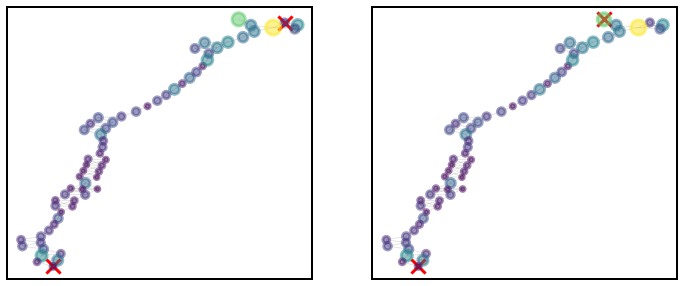

In [110]:
cv = pltext.canvas(2, 2)
cv(1)
u, v, dist = graphfun.graph_extremes(graph)
print('extremes distance:', dist, ", extrenes nodes:", u, v)
graphfun.display_graph(graph, (u, v))
cv(2)
u, v, dist = graphfun.graph_extremes(longest_graph)
print('extremes distance:', dist, ", extrenes nodes:", u, v)
graphfun.display_graph(longest_graph, (u, v))

## Get Blobs

In [112]:
blobs, extremes = graphfun.get_blobs(longest_graph, (u, v), distance = 3)

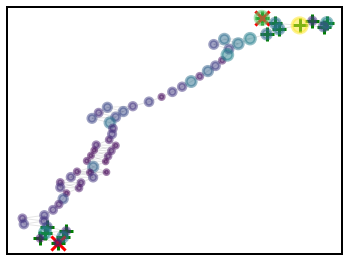

In [113]:
cv = pltext.canvas(2, 1)
cv(1)
graphfun.display_graph(graph, extremes = (u, v), blobs = blobs)

## Event summary

In [115]:
dfsum = evtfun.summary_data(data)
dfsum = pd.DataFrame(dfsum)
dfsum.head()

,dataset_id,nhits,energy,spine_nhits,spine_energy
dataset_id,,,,,
0,0,611,1.0,363,0.825074
1,1,688,1.0,175,0.513415
2,2,656,1.0,73,0.241817
3,3,526,1.0,355,0.878824
4,4,638,1.0,463,0.885814


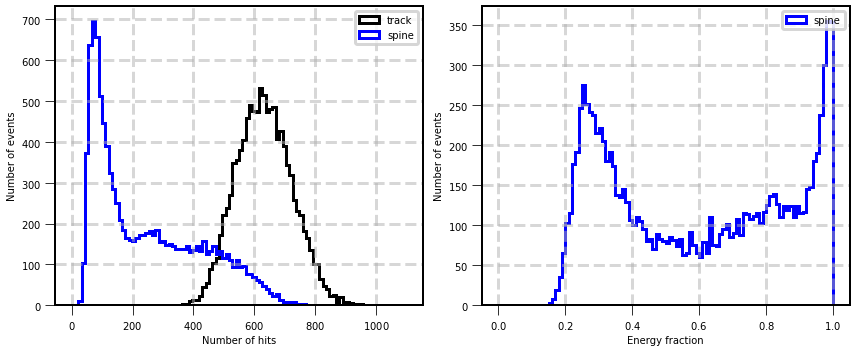

In [116]:
cv = pltext.canvas(2, 2)
cv(1), pltext.hist(dfsum.nhits      ,  bins = 100, range = (0, 1100), stats = False, label = 'track');
cv(1), pltext.hist(dfsum.spine_nhits,  bins = 100, range = (0, 1100), stats = False, label = 'spine', color = 'blue');
plt.xlabel('Number of hits'); plt.ylabel('Number of events'); plt.legend();
#cv(2), pltext.hist(dfsum.energy      ,  bins = 100, range = (0, 1), stats = False, label = 'track');
cv(2), pltext.hist(dfsum.spine_energy,  bins = 100, range = (0, 1), stats = False, label = 'spine', color = 'blue');
plt.xlabel('Energy fraction'); plt.ylabel('Number of events'); plt.legend();
plt.tight_layout()
